# CNN "from scratch" vs Transfert Learning — Cats vs Dogs

**Objectif** : comparer un CNN entraîné from scratch (Expérience A) et un ResNet18 pré-entraîné adapté par transfert d'apprentissage (Expérience B) sur la classification chats / chiens, avec deux optimiseurs (Adam, SGD) par expérience.

**Exécution** : entraînement prévu sur **Google Colab (GPU T4)**. Chaque run sauvegarde son meilleur modèle (`checkpoints/`), un point de reprise et son historique de métriques (`results/`). Relancer le notebook **saute les runs déjà terminés** et reprend un run interrompu à l'époque suivante.

In [1]:
import json
import os
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18

## 1. Environnement : GPU, Google Drive, données

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/deep_learning')

DATA_DIR = 'Cat_Dog_data'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Dossier de travail :", os.getcwd())
print("Device             :", torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU (aucun GPU détecté)')

## 2. Configuration

`FAST_DEBUG=1` (variable d'environnement) lance un mini-run sur un sous-échantillon pour vérifier le code sans GPU ; ses fichiers sont écrits dans des sous-dossiers `debug/` séparés. Sans cette variable, le notebook fait l'entraînement complet.

Le transfert learning converge en quelques époques (backbone gelé, seule la tête est entraînée), d'où `EPOCHS_B < EPOCHS_A`.

In [3]:
FAST_DEBUG = os.environ.get('FAST_DEBUG', '0') == '1'

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 8 if FAST_DEBUG else 32
EPOCHS_A = 2 if FAST_DEBUG else 15
EPOCHS_B = 2 if FAST_DEBUG else 5
STEP_SIZE = 5
VAL_FRACTION = 0.2
SUBSET_PER_CLASS_TRAIN = 40 if FAST_DEBUG else None
SUBSET_PER_CLASS_TEST = 16 if FAST_DEBUG else None
NUM_WORKERS = 2 if IN_COLAB else 0
RESUME = True

sub = 'debug' if FAST_DEBUG else ''
CKPT_DIR = Path('checkpoints') / sub
RESULTS_DIR = Path('results') / sub
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
print(f"FAST_DEBUG={FAST_DEBUG} | EPOCHS_A={EPOCHS_A} | EPOCHS_B={EPOCHS_B} | BATCH_SIZE={BATCH_SIZE}")

FAST_DEBUG=False | EPOCHS_A=15 | EPOCHS_B=5 | BATCH_SIZE=32


## 3. Données

- **Train** : rotation, recadrage aléatoire et flip horizontal (augmentation).
- **Validation / test** : redimensionnement + recadrage central, sans augmentation.
- **Normalisation** ImageNet pour les deux expériences (indispensable au transfert learning).
- **Split train / validation** 80/20 tiré aléatoirement (seed fixée) depuis `train/` ; le jeu `test/` n'est utilisé qu'à la fin.

In [4]:
def balanced_indices(dataset, per_class, seed=SEED):
    if per_class is None:
        return list(range(len(dataset)))
    rng = random.Random(seed)
    by_class = {}
    for idx, (_, label) in enumerate(dataset.samples):
        by_class.setdefault(label, []).append(idx)
    chosen = []
    for idxs in by_class.values():
        rng.shuffle(idxs)
        chosen.extend(idxs[:per_class])
    return chosen


mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 16),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 16),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

full_train_aug = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
full_train_plain = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=eval_transforms)
full_test = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=eval_transforms)
class_names = full_train_aug.classes

base_indices = balanced_indices(full_train_aug, SUBSET_PER_CLASS_TRAIN)
perm = torch.randperm(len(base_indices), generator=torch.Generator().manual_seed(SEED)).tolist()
n_val = int(len(base_indices) * VAL_FRACTION)
val_idx = [base_indices[i] for i in perm[:n_val]]
train_idx = [base_indices[i] for i in perm[n_val:]]

train_data = Subset(full_train_aug, train_idx)
val_data = Subset(full_train_plain, val_idx)
test_data = Subset(full_test, balanced_indices(full_test, SUBSET_PER_CLASS_TEST))

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=device.type == 'cuda')
train_loader = DataLoader(train_data, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_data, **loader_kwargs)
test_loader = DataLoader(test_data, **loader_kwargs)

print("Classes :", class_names)
print(f"train={len(train_data)}  val={len(val_data)}  test={len(test_data)}")

Classes : ['cat', 'dog']
train=18000  val=4500  test=2516


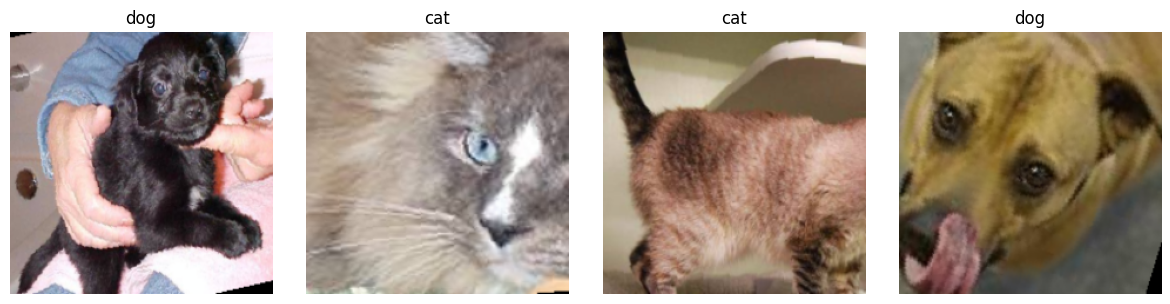

In [5]:
def denormalize(img):
    img = img.numpy().transpose(1, 2, 0)
    return np.clip(np.array(std) * img + np.array(mean), 0, 1)


images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, label in zip(axes, images, labels):
    ax.imshow(denormalize(img))
    ax.set_title(class_names[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Fonctions d'entraînement et d'évaluation

`train_run` entraîne un modèle en sauvegardant à chaque époque : le **meilleur modèle** (`*_best.pt`, selon `val_acc`), un **point de reprise** (`*_last.pt` : modèle, optimiseur, scheduler) et l'**historique** (`results/*_history.json`). Si l'historique d'un run est déjà complet, il est simplement rechargé.

In [6]:
HISTORY_KEYS = ['train_loss', 'train_acc', 'train_prec', 'train_rec',
                'val_loss', 'val_acc', 'val_prec', 'val_rec', 'time']


def compute_metrics(y_true, y_pred):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0))


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(outputs.argmax(1).cpu().tolist())
    return (total_loss / len(y_true), *compute_metrics(y_true, y_pred))


def train_run(name, model, optimizer, scheduler, epochs):
    best_path, last_path = CKPT_DIR / f'{name}_best.pt', CKPT_DIR / f'{name}_last.pt'
    hist_path = RESULTS_DIR / f'{name}_history.json'
    history = {k: [] for k in HISTORY_KEYS}

    if RESUME and hist_path.exists():
        history = json.loads(hist_path.read_text())
        done = len(history['val_acc'])
        if done < epochs and last_path.exists():
            state = torch.load(last_path, map_location=device, weights_only=True)
            model.load_state_dict(state['model'])
            optimizer.load_state_dict(state['optimizer'])
            scheduler.load_state_dict(state['scheduler'])
            print(f"[{name}] reprise à l'époque {done + 1}/{epochs}")
        elif done < epochs:
            print(f"[{name}] point de reprise absent : réentraînement complet")
            history = {k: [] for k in HISTORY_KEYS}
        else:
            print(f"[{name}] déjà entraîné ({done} époques) : historique rechargé")

    criterion = nn.CrossEntropyLoss()
    best_val_acc = max(history['val_acc'], default=-1.0)
    for epoch in range(len(history['val_acc']) + 1, epochs + 1):
        start = time.time()
        train_m = run_epoch(model, train_loader, criterion, optimizer)
        val_m = run_epoch(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - start
        for key, value in zip(HISTORY_KEYS, (*train_m, *val_m, elapsed)):
            history[key].append(value)
        if val_m[1] > best_val_acc:
            best_val_acc = val_m[1]
            torch.save(model.state_dict(), best_path)
        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict()}, last_path)
        hist_path.write_text(json.dumps(history, indent=1))
        print(f"[{name}] epoch {epoch}/{epochs} | "
              f"train loss={train_m[0]:.4f} acc={train_m[1]:.3f} prec={train_m[2]:.3f} rec={train_m[3]:.3f} | "
              f"val loss={val_m[0]:.4f} acc={val_m[1]:.3f} prec={val_m[2]:.3f} rec={val_m[3]:.3f} | {elapsed:.0f}s")
    return history


OPTIMIZERS = {'adam': (optim.Adam, {'lr': 1e-3}),
              'sgd': (optim.SGD, {'lr': 1e-2, 'momentum': 0.9})}


def run_experiment(experiment, opt_name, build_model, epochs):
    set_seed(SEED)
    model = build_model().to(device)
    opt_cls, opt_kwargs = OPTIMIZERS[opt_name]
    optimizer = opt_cls([p for p in model.parameters() if p.requires_grad], **opt_kwargs)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=0.5)
    return train_run(f'{experiment}_{opt_name}', model, optimizer, scheduler, epochs)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, metric in zip(axes[:2], ('loss', 'acc')):
        ax.plot(history[f'train_{metric}'], label='train')
        ax.plot(history[f'val_{metric}'], label='val')
        ax.set_title(metric)
    axes[2].plot(history['train_prec'], label='train precision')
    axes[2].plot(history['val_prec'], label='val precision')
    axes[2].plot(history['train_rec'], '--', label='train recall')
    axes[2].plot(history['val_rec'], '--', label='val recall')
    axes[2].set_title('precision / recall')
    for ax in axes:
        ax.set_xlabel('epoch')
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def best_run(experiment, results):
    candidates = {n: h for n, h in results.items() if n.startswith(experiment)}
    return max(candidates, key=lambda n: max(candidates[n]['val_acc']))

## 5. Expérience A — CNN from scratch

4 blocs `Conv2d → BatchNorm2d → ReLU → MaxPool2d` (3 minimum demandés), puis une tête dense avec Dropout.

- **BatchNorm après chaque convolution** : normalise les activations, stabilise et accélère l'entraînement, autorise un learning rate plus élevé.
- **Dropout dans la tête dense** : c'est là que se concentre la majorité des paramètres, donc le risque de sur-apprentissage ; le Dropout force des représentations redondantes.
- **`AdaptiveAvgPool2d`** avant la tête : la taille de la couche dense ne dépend pas de la résolution d'entrée.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


build_scratch = lambda: SimpleCNN(num_classes=len(class_names))
print(build_scratch())

SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0

In [8]:
results = {}
results['A_scratch_adam'] = run_experiment('A_scratch', 'adam', build_scratch, EPOCHS_A)

[A_scratch_adam] déjà entraîné (15 époques) : historique rechargé


In [9]:
results['A_scratch_sgd'] = run_experiment('A_scratch', 'sgd', build_scratch, EPOCHS_A)

[A_scratch_sgd] déjà entraîné (15 époques) : historique rechargé


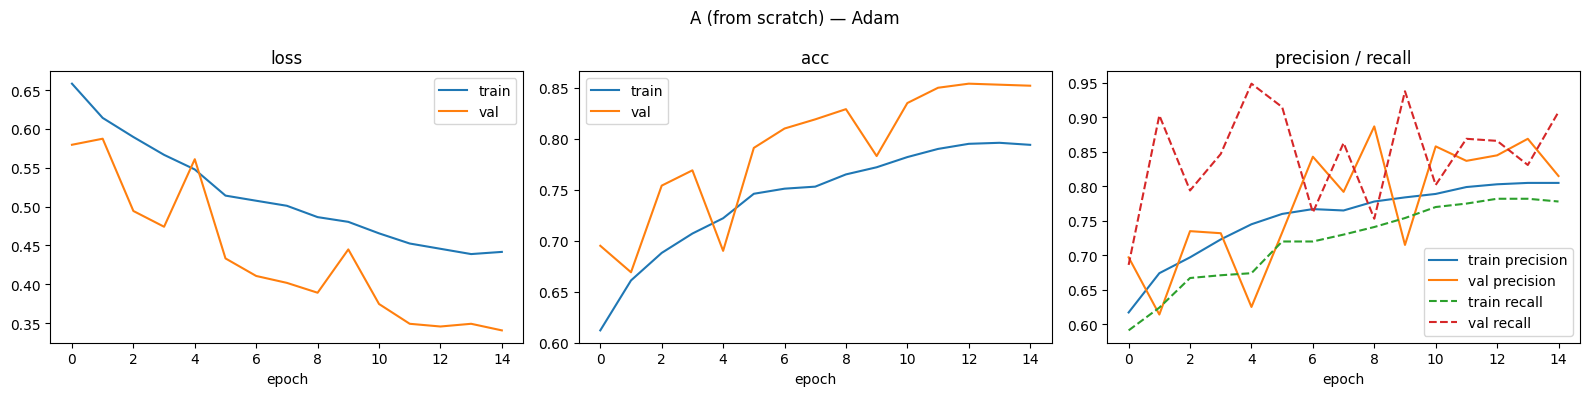

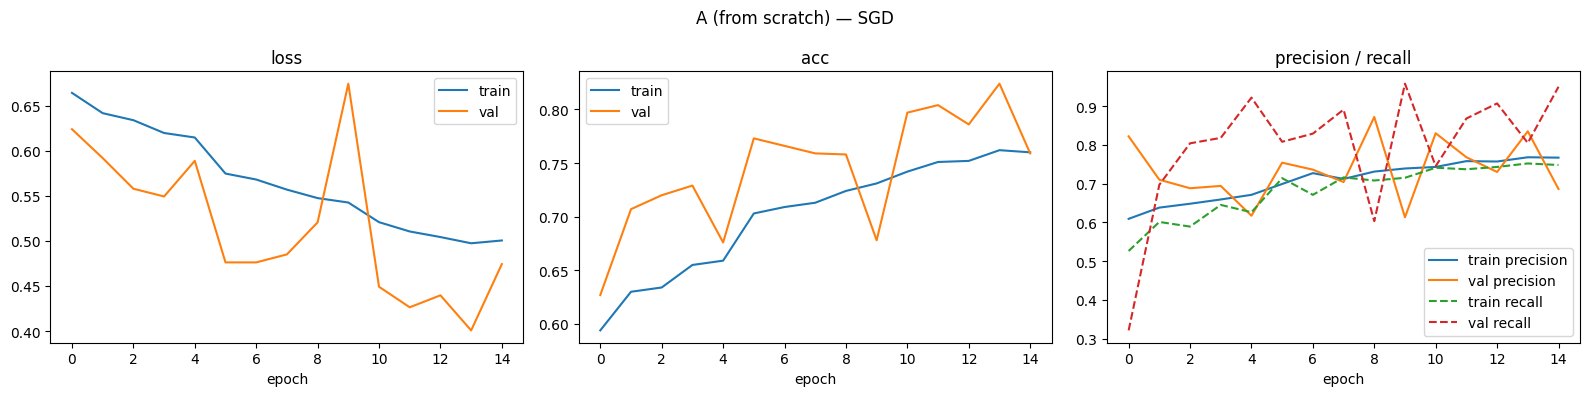

In [10]:
plot_history(results['A_scratch_adam'], 'A (from scratch) — Adam')
plot_history(results['A_scratch_sgd'], 'A (from scratch) — SGD')

## 6. Expérience B — Transfert learning (ResNet18 pré-entraîné ImageNet)

Le backbone est **gelé** (`requires_grad=False`) et la couche finale est remplacée par `Dropout(0.5) → Linear(512, 2)`, seule partie entraînée. Le backbone contient déjà des couches `BatchNorm` pré-entraînées ; le Dropout régularise la nouvelle tête. Comme le backbone est gelé, seule la tête reçoit des gradients : l'optimiseur ne reçoit que les paramètres entraînables.

In [11]:
def build_transfer(num_classes=2):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    return model


build_transfer_model = lambda: build_transfer(len(class_names))

In [12]:
results['B_transfer_adam'] = run_experiment('B_transfer', 'adam', build_transfer_model, EPOCHS_B)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


[B_transfer_adam] déjà entraîné (5 époques) : historique rechargé


In [13]:
results['B_transfer_sgd'] = run_experiment('B_transfer', 'sgd', build_transfer_model, EPOCHS_B)

[B_transfer_sgd] epoch 1/5 | train loss=0.6441 acc=0.845 prec=0.845 rec=0.845 | val loss=0.1449 acc=0.965 prec=0.990 rec=0.939 | 120s
[B_transfer_sgd] epoch 2/5 | train loss=0.7810 acc=0.858 prec=0.858 rec=0.858 | val loss=0.1251 acc=0.968 prec=0.956 rec=0.980 | 119s
[B_transfer_sgd] epoch 3/5 | train loss=0.6402 acc=0.862 prec=0.863 rec=0.862 | val loss=0.2127 acc=0.947 prec=0.996 rec=0.897 | 116s
[B_transfer_sgd] epoch 4/5 | train loss=0.6860 acc=0.859 prec=0.859 rec=0.858 | val loss=0.1109 acc=0.969 prec=0.971 rec=0.967 | 115s
[B_transfer_sgd] epoch 5/5 | train loss=0.7404 acc=0.853 prec=0.853 rec=0.852 | val loss=0.1193 acc=0.968 prec=0.960 rec=0.976 | 115s


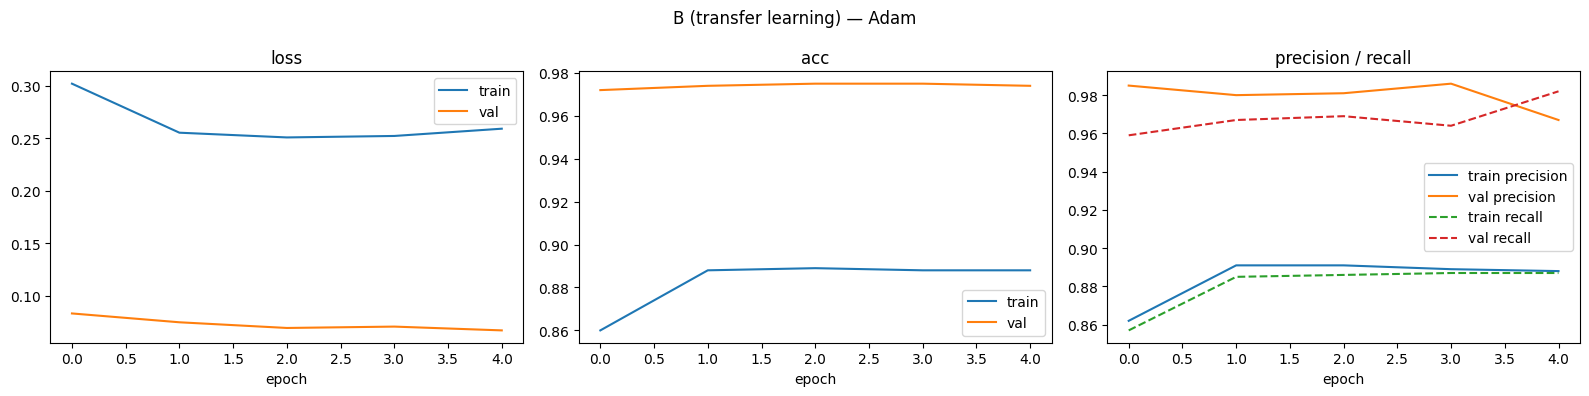

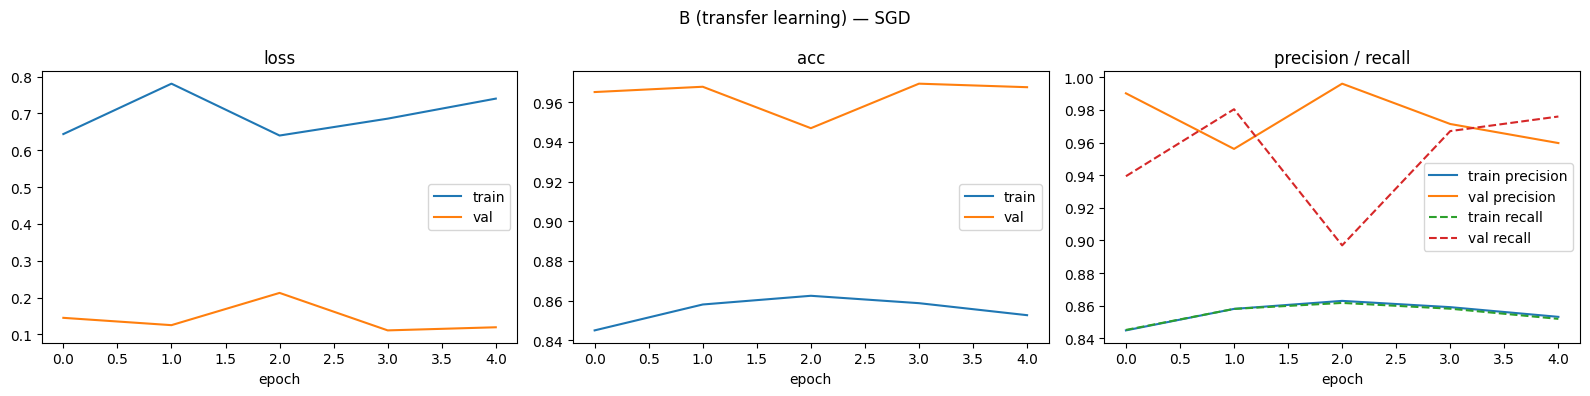

In [14]:
plot_history(results['B_transfer_adam'], 'B (transfer learning) — Adam')
plot_history(results['B_transfer_sgd'], 'B (transfer learning) — SGD')

## 7. Comparaison des runs (validation)

In [15]:
rows = []
for name, h in results.items():
    best = int(np.argmax(h['val_acc']))
    rows.append({'run': name, 'epochs': len(h['val_acc']), 'best_epoch': best + 1,
                 'val_loss': h['val_loss'][best], 'val_acc': h['val_acc'][best],
                 'val_prec': h['val_prec'][best], 'val_rec': h['val_rec'][best],
                 'median_epoch_s': float(np.median(h['time']))})
summary_val = pd.DataFrame(rows).set_index('run').round(3)
summary_val.to_csv(RESULTS_DIR / 'validation_summary.csv')
summary_val

,epochs,best_epoch,val_loss,val_acc,val_prec,val_rec,median_epoch_s
run,,,,,,,
A_scratch_adam,15,13,0.346,0.854,0.845,0.866,212.000
A_scratch_sgd,15,14,0.401,0.824,0.835,0.805,205.400
B_transfer_adam,5,3,0.070,0.975,0.981,0.969,179.200
B_transfer_sgd,5,4,0.111,0.969,0.971,0.967,115.661


Meilleur run A : A_scratch_adam | Meilleur run B : B_transfer_adam


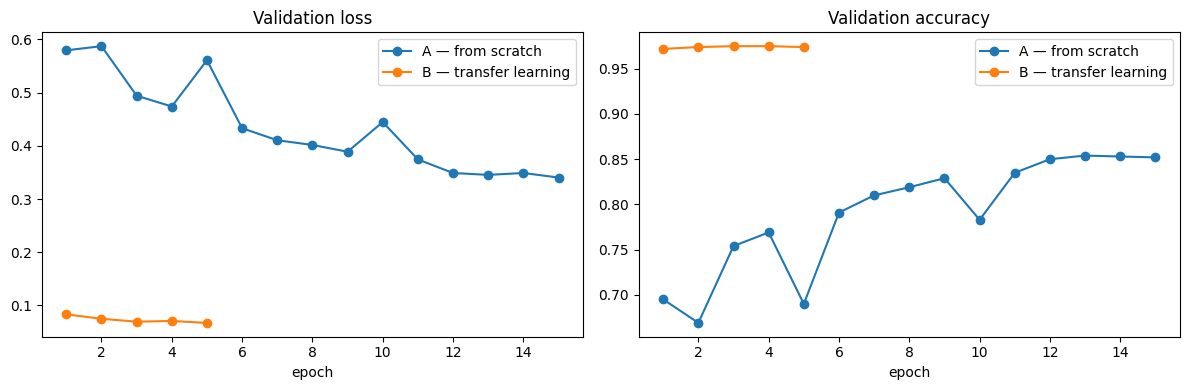

In [16]:
best_A, best_B = best_run('A_scratch', results), best_run('B_transfer', results)
print("Meilleur run A :", best_A, "| Meilleur run B :", best_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, label in ((best_A, 'A — from scratch'), (best_B, 'B — transfer learning')):
    axes[0].plot(range(1, len(results[name]['val_loss']) + 1), results[name]['val_loss'], marker='o', label=label)
    axes[1].plot(range(1, len(results[name]['val_acc']) + 1), results[name]['val_acc'], marker='o', label=label)
axes[0].set_title('Validation loss')
axes[1].set_title('Validation accuracy')
for ax in axes:
    ax.set_xlabel('epoch')
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Test final — rechargement des meilleurs modèles depuis le disque

Des modèles neufs sont instanciés, les poids sauvegardés (`checkpoints/*_best.pt`) sont rechargés, puis évalués sur le jeu de **test**, jamais vu à l'entraînement.

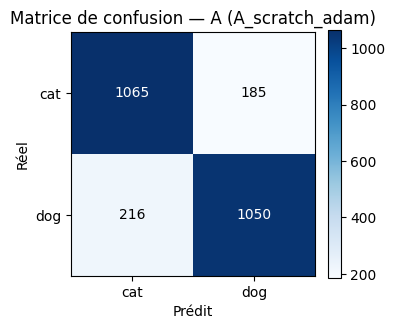

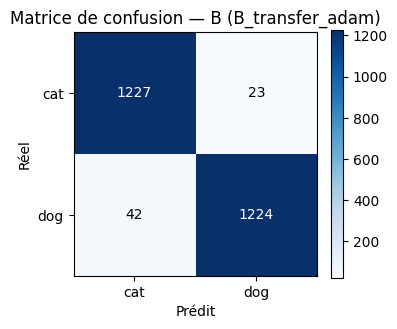

,loss,accuracy,precision,recall
A — A_scratch_adam,0.364,0.841,0.850,0.829
B — B_transfer_adam,0.069,0.974,0.982,0.967


In [17]:
def load_best(build_model, name):
    model = build_model().to(device)
    model.load_state_dict(torch.load(CKPT_DIR / f'{name}_best.pt', map_location=device, weights_only=True))
    return model.eval()


def evaluate_on_test(model, title):
    criterion = nn.CrossEntropyLoss()
    y_true, y_pred, total_loss = [], [], 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(outputs.argmax(1).cpu().tolist())
    acc, prec, rec = compute_metrics(y_true, y_pred)
    metrics = {'loss': total_loss / len(y_true), 'accuracy': acc, 'precision': prec, 'recall': rec}

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(class_names)), class_names)
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(f'Matrice de confusion — {title}')
    for i, j in np.ndindex(cm.shape):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()
    return metrics


final_A = load_best(build_scratch, best_A)
final_B = load_best(build_transfer_model, best_B)
metrics_A = evaluate_on_test(final_A, f'A ({best_A})')
metrics_B = evaluate_on_test(final_B, f'B ({best_B})')

summary_test = pd.DataFrame({f'A — {best_A}': metrics_A, f'B — {best_B}': metrics_B}).T.round(3)
summary_test.to_csv(RESULTS_DIR / 'test_summary.csv')
summary_test

### Erreurs typiques

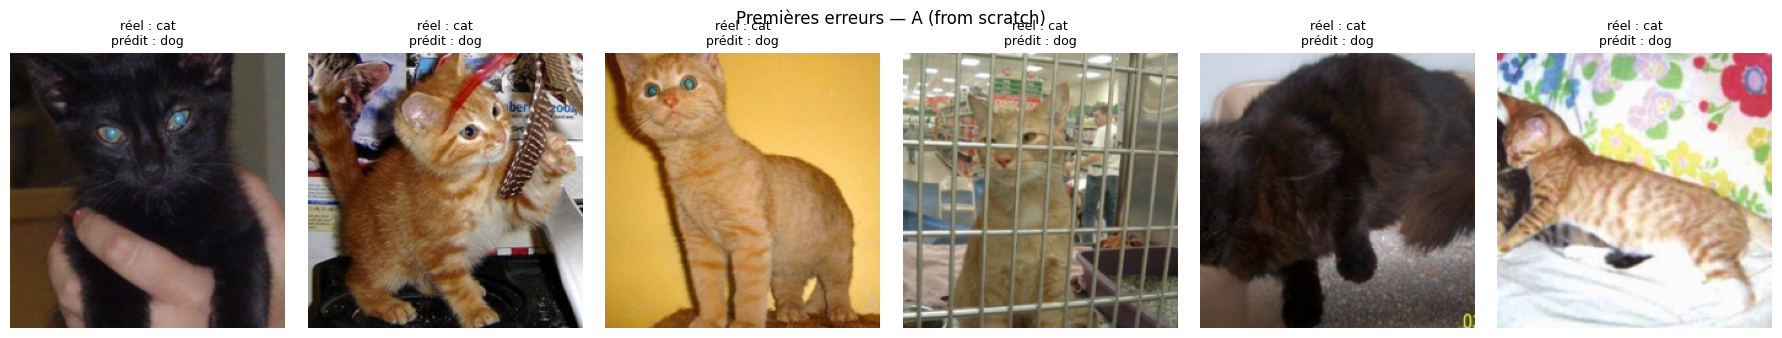

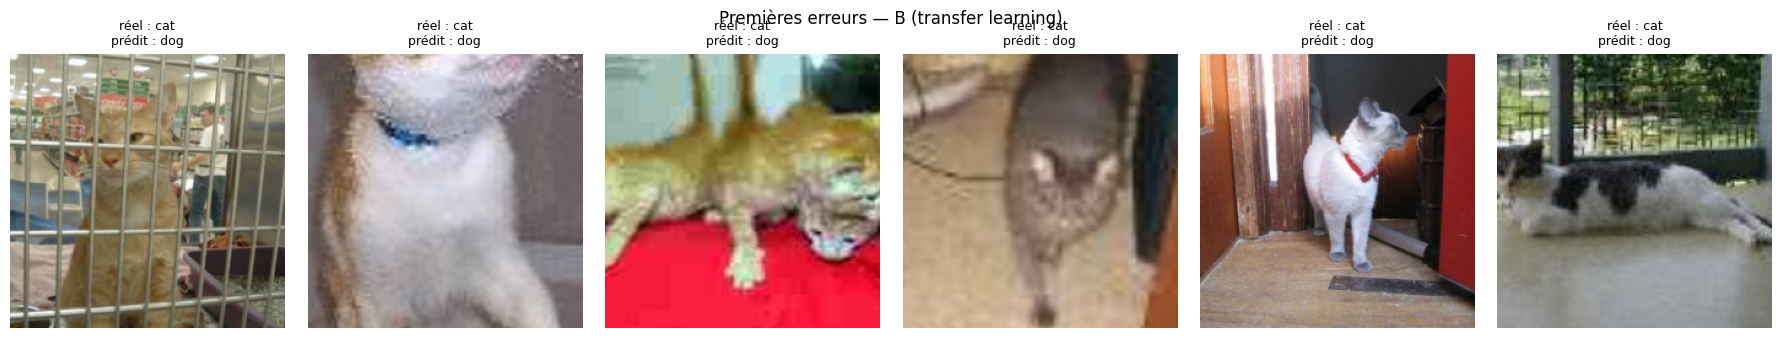

In [18]:
def show_errors(model, title, n=6):
    errors = []
    with torch.no_grad():
        for i in range(len(test_data)):
            img, label = test_data[i]
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
            if pred != label:
                errors.append((img, label, pred))
            if len(errors) == n:
                break
    if not errors:
        print("Aucune erreur trouvée.")
        return
    fig, axes = plt.subplots(1, len(errors), figsize=(3 * len(errors), 3.4))
    for ax, (img, label, pred) in zip(np.atleast_1d(axes), errors):
        ax.imshow(denormalize(img))
        ax.set_title(f'réel : {class_names[label]}\nprédit : {class_names[pred]}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_errors(final_A, 'Premières erreurs — A (from scratch)')
show_errors(final_B, 'Premières erreurs — B (transfer learning)')

## 9. Analyse

Les chiffres de référence sont ceux des tableaux ci-dessus (validation puis test) ; les observations suivantes s'appuient sur les runs effectués sur GPU T4.

- **Convergence** : le transfert learning atteint dès la 1re époque environ 97 % de précision en validation, alors que le CNN from scratch en est à ~70 % et n'atteint ~85 % qu'après 13 à 15 époques. Les features ImageNet sont directement exploitables.
- **Optimiseurs** : pour le CNN from scratch, Adam converge un peu plus vite que SGD avec momentum (train loss plus basse à chaque époque, meilleure val_acc 0.854 contre 0.824). Les deux restent bruités en validation, SGD davantage (recall de 0.60 à 0.96 selon les époques dès la 5e).
- **Régularisation** : en entraînement, l'accuracy est inférieure à celle de validation (dropout actif et augmentation de données présents uniquement à l'entraînement) : pas de sur-apprentissage visible dans les deux expériences.
- **Robustesse** : la validation du CNN from scratch est instable d'une époque à l'autre (recall qui passe de 0.75 à 0.95), signe d'un modèle encore sensible aux données vues ; le modèle de transfert reste stable (précision et recall > 0.95 dès la 1re époque).
- **Limites** : backbone entièrement gelé (un fine-tuning des derniers blocs pourrait encore gagner), un seul backbone testé, pas de recherche d'hyperparamètres systématique, expérience B limitée à 5 époques car elle a convergé dès les premières.